In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import warnings
from itertools import product as iproduct

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

XLSX_PATH = '/content/capstone_dataset.xlsx'

print('Reading Excel file (this takes ~30s for a large workbook)...')
wb = openpyxl.load_workbook(XLSX_PATH, read_only=True, data_only=True)
print(f'Sheets found: {wb.sheetnames}')

# ---------- Table 1: sequences ----------
ws1 = wb['Supplementary Table 1']
rows1 = list(ws1.iter_rows(values_only=True))[4:]
seq_dict = {r[0]: r[11] for r in rows1 if r[0] and r[11]}
print(f'Table 1 — sequences loaded: {len(seq_dict):,}')

# ---------- Table 2: expression ----------
ws2 = wb['Supplementary Table 2']
rows2 = list(ws2.iter_rows(values_only=True))[4:]
exp_dict = {r[0]: {'species': r[1], 'expr': r[2:8]} for r in rows2 if r[0]}
print(f'Table 2 — expression records loaded: {len(exp_dict):,}')

# ---------- Merge ----------
COND_COLS = [
    'no_enhancer_dark_tobacco',
    'no_enhancer_dark_maize',
    'with_enhancer_dark_tobacco',
    'with_enhancer_dark_maize',
    'no_enhancer_light_tobacco',
    'with_enhancer_light_tobacco',
]

records = []
for gene in set(seq_dict) & set(exp_dict):
    vals = exp_dict[gene]['expr']
    if all(v is not None and v != '#N/A' for v in vals):
        row = {'gene': gene, 'species': exp_dict[gene]['species'], 'sequence': seq_dict[gene]}
        for col, v in zip(COND_COLS, vals):
            row[col] = float(v)
        records.append(row)

df = pd.DataFrame(records)

print(f'\nMerged dataset: {len(df):,} promoters with complete data')
print(df['species'].value_counts().to_string())
df.head()

Reading Excel file (this takes ~30s for a large workbook)...
Sheets found: ['Supplementary Table 1', 'Supplementary Table 2', 'Supplementary Table 3', 'Supplementary Table 4', 'Supplementary Table 5', 'Supplementary Table 6', 'Supplementary Table 7', 'Supplementary Table 8', 'Supplementary Table 9', 'Supplementary Table 10', 'Supplementary Table 11']
Table 1 — sequences loaded: 79,838
Table 2 — expression records loaded: 78,677

Merged dataset: 67,860 promoters with complete data
species
Maize          29002
Sorghum        23470
Arabidopsis    15388


,gene,species,sequence,no_enhancer_dark_tobacco,no_enhancer_dark_maize,with_enhancer_dark_tobacco,with_enhancer_dark_maize,no_enhancer_light_tobacco,with_enhancer_light_tobacco
0,AT5G23870,Arabidopsis,TCTATTTTTAAAGCTAAAGTTCTTAAGGAAGAAAATATCATGTGGA...,0.127234,-2.624965,1.298207,-0.996849,-0.492678,1.218890
1,SORBI_3002G154700,Sorghum,TTTTCGTCTATATTTAATGTTTCATACACGTGTCACAAGATTCGAT...,0.626410,-0.219951,1.356029,0.047292,-1.366348,0.857437
2,SORBI_3002G167300,Sorghum,CCCTAGTTTCTCTGTGTTGTGTGTTCAACGTGCTATCTTCTCGAGA...,-3.938925,-1.288401,-0.755530,0.912564,-4.673696,-1.428208
3,SORBI_3001G344450,Sorghum,ACCCAAACAGCATGCTCCAGTCCAGAGTCCAGTCCAGTCCAGTCCA...,-2.345986,-3.067102,0.452914,-0.791722,-2.767965,-0.909089
4,Zm00001d006471,Maize,AGAGCTGGCGGCAGTTATGATTTCTGGATGATGCAGTGGAGCCATG...,-3.498617,-2.764727,-1.336180,-0.992872,-3.640760,-1.653512


In [19]:
df = df.dropna(subset=['sequence']).copy()
df['sequence'] = df['sequence'].str.upper()

valid_chars = set("ATCG")
df = df[df['sequence'].apply(lambda x: set(x).issubset(valid_chars))].copy()

print("After cleaning:", df.shape)

After cleaning: (67860, 9)


In [20]:
SEQ_LEN = 170

def fix_sequence_length(seq, length=SEQ_LEN):
    seq = seq[:length]
    if len(seq) < length:
        seq = seq + 'A' * (length - len(seq))
    return seq

df['sequence'] = df['sequence'].apply(lambda x: fix_sequence_length(x, SEQ_LEN))
print("Sequence length standardized.")

Sequence length standardized.


In [21]:
def one_hot_encode(seq, seq_len=SEQ_LEN):
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    mat = np.zeros((4, seq_len), dtype=np.float32)
    for i, nt in enumerate(seq[:seq_len]):
        if nt in mapping:
            mat[mapping[nt], i] = 1.0
    return mat.flatten()


def kmer_features(seq, k=4):
    kmers = [''.join(p) for p in iproduct('ATCG', repeat=k)]
    kmer_idx = {km: i for i, km in enumerate(kmers)}
    vec = np.zeros(len(kmers), dtype=np.float32)

    for i in range(len(seq) - k + 1):
        km = seq[i:i+k]
        if km in kmer_idx:
            vec[kmer_idx[km]] += 1

    total = vec.sum()
    if total > 0:
        vec /= total

    return vec


def gc_content(seq):
    gc = seq.count('G') + seq.count('C')
    return gc / len(seq)


def gc_windows(seq, window_size=20):
    vals = []
    for i in range(0, len(seq), window_size):
        window = seq[i:i+window_size]
        if len(window) > 0:
            gc = (window.count('G') + window.count('C')) / len(window)
            vals.append(gc)
    return np.array(vals, dtype=np.float32)


MOTIFS = ['TATA', 'CAAT', 'CGCG', 'GATA', 'AATAAA']

def motif_features(seq, motifs=MOTIFS):
    return np.array([seq.count(m) for m in motifs], dtype=np.float32)

In [22]:
species_dummies = pd.get_dummies(df['species'], prefix='species')
species_dummies.head()

,species_Arabidopsis,species_Maize,species_Sorghum
0,True,False,False
1,False,False,True
2,False,False,True
3,False,False,True
4,False,True,False


In [23]:
X_features = []

for i, row in df.iterrows():
    seq = row['sequence']

    onehot = one_hot_encode(seq)
    kmer4 = kmer_features(seq, k=4)
    gc = np.array([gc_content(seq)], dtype=np.float32)
    gc_win = gc_windows(seq, window_size=20)
    motifs = motif_features(seq)

    seq_features = np.concatenate([onehot, kmer4, gc, gc_win, motifs])
    species_feat = species_dummies.loc[i].values.astype(np.float32)

    combined = np.concatenate([seq_features, species_feat])
    X_features.append(combined)

X = np.array(X_features, dtype=np.float32)

print("Final X shape:", X.shape)

Final X shape: (67860, 954)


In [24]:
Y = df[COND_COLS].values.astype(np.float32)
print("Final Y shape:", Y.shape)

Final Y shape: (67860, 6)


In [25]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
Y_train, Y_val, Y_test = Y[train_idx], Y[val_idx], Y[test_idx]

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (47502, 954) (47502, 6)
Val  : (10179, 954) (10179, 6)
Test : (10179, 954) (10179, 6)


In [27]:
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{name}")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("-" * 30)

In [28]:
models = {}
results = []

for j, col in enumerate(COND_COLS):
    print(f"\nTraining model for: {col}")

    y_train = Y_train[:, j]
    y_val = Y_val[:, j]
    y_test = Y_test[:, j]

    model = XGBRegressor(
        n_estimators=1200,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_weight=3,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    print_metrics("Train", y_train, train_pred)
    print_metrics("Validation", y_val, val_pred)
    print_metrics("Test", y_test, test_pred)

    models[col] = model
    results.append({
        'condition': col,
        'train_r2': r2_score(y_train, train_pred),
        'val_r2': r2_score(y_val, val_pred),
        'test_r2': r2_score(y_test, test_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'test_mae': mean_absolute_error(y_test, test_pred)
    })


Training model for: no_enhancer_dark_tobacco
Train
R2   : 0.7725
RMSE : 0.6326
MAE  : 0.4870
------------------------------
Validation
R2   : 0.5012
RMSE : 0.9413
MAE  : 0.7097
------------------------------
Test
R2   : 0.5067
RMSE : 0.9331
MAE  : 0.7044
------------------------------

Training model for: no_enhancer_dark_maize
Train
R2   : 0.7548
RMSE : 0.5463
MAE  : 0.4212
------------------------------
Validation
R2   : 0.4887
RMSE : 0.7938
MAE  : 0.6044
------------------------------
Test
R2   : 0.5050
RMSE : 0.7985
MAE  : 0.6089
------------------------------

Training model for: with_enhancer_dark_tobacco
Train
R2   : 0.7985
RMSE : 0.7504
MAE  : 0.5932
------------------------------
Validation
R2   : 0.5774
RMSE : 1.0826
MAE  : 0.8460
------------------------------
Test
R2   : 0.5721
RMSE : 1.0952
MAE  : 0.8563
------------------------------

Training model for: with_enhancer_dark_maize
Train
R2   : 0.7812
RMSE : 0.5811
MAE  : 0.4538
------------------------------
Validation
R2 

In [29]:
results_df = pd.DataFrame(results)
results_df

,condition,train_r2,val_r2,test_r2,test_rmse,test_mae
0,no_enhancer_dark_tobacco,0.772543,0.501211,0.506734,0.933068,0.704360
1,no_enhancer_dark_maize,0.754800,0.488699,0.504985,0.798543,0.608870
2,with_enhancer_dark_tobacco,0.798480,0.577362,0.572071,1.095210,0.856318
3,with_enhancer_dark_maize,0.781204,0.527804,0.553096,0.851402,0.661082
4,no_enhancer_light_tobacco,0.754862,0.486161,0.481547,1.051172,0.812025
5,with_enhancer_light_tobacco,0.801235,0.588109,0.583881,1.124899,0.882269


In [30]:
print(results_df.sort_values('test_r2', ascending=False).to_string(index=False))

                  condition  train_r2   val_r2  test_r2  test_rmse  test_mae
with_enhancer_light_tobacco  0.801235 0.588109 0.583881   1.124899  0.882269
 with_enhancer_dark_tobacco  0.798480 0.577362 0.572071   1.095210  0.856318
   with_enhancer_dark_maize  0.781204 0.527804 0.553096   0.851402  0.661082
   no_enhancer_dark_tobacco  0.772543 0.501211 0.506734   0.933068  0.704360
     no_enhancer_dark_maize  0.754800 0.488699 0.504985   0.798543  0.608870
  no_enhancer_light_tobacco  0.754862 0.486161 0.481547   1.051172  0.812025


In [34]:
print("Average train R2:", results_df['train_r2'].mean())
print("Average test R2:", results_df['test_r2'].mean())
print("Average validation R2:", results_df['val_r2'].mean())

Average train R2: 0.7771872878074646
Average test R2: 0.5337189535299937
Average validation R2: 0.5282242695490519


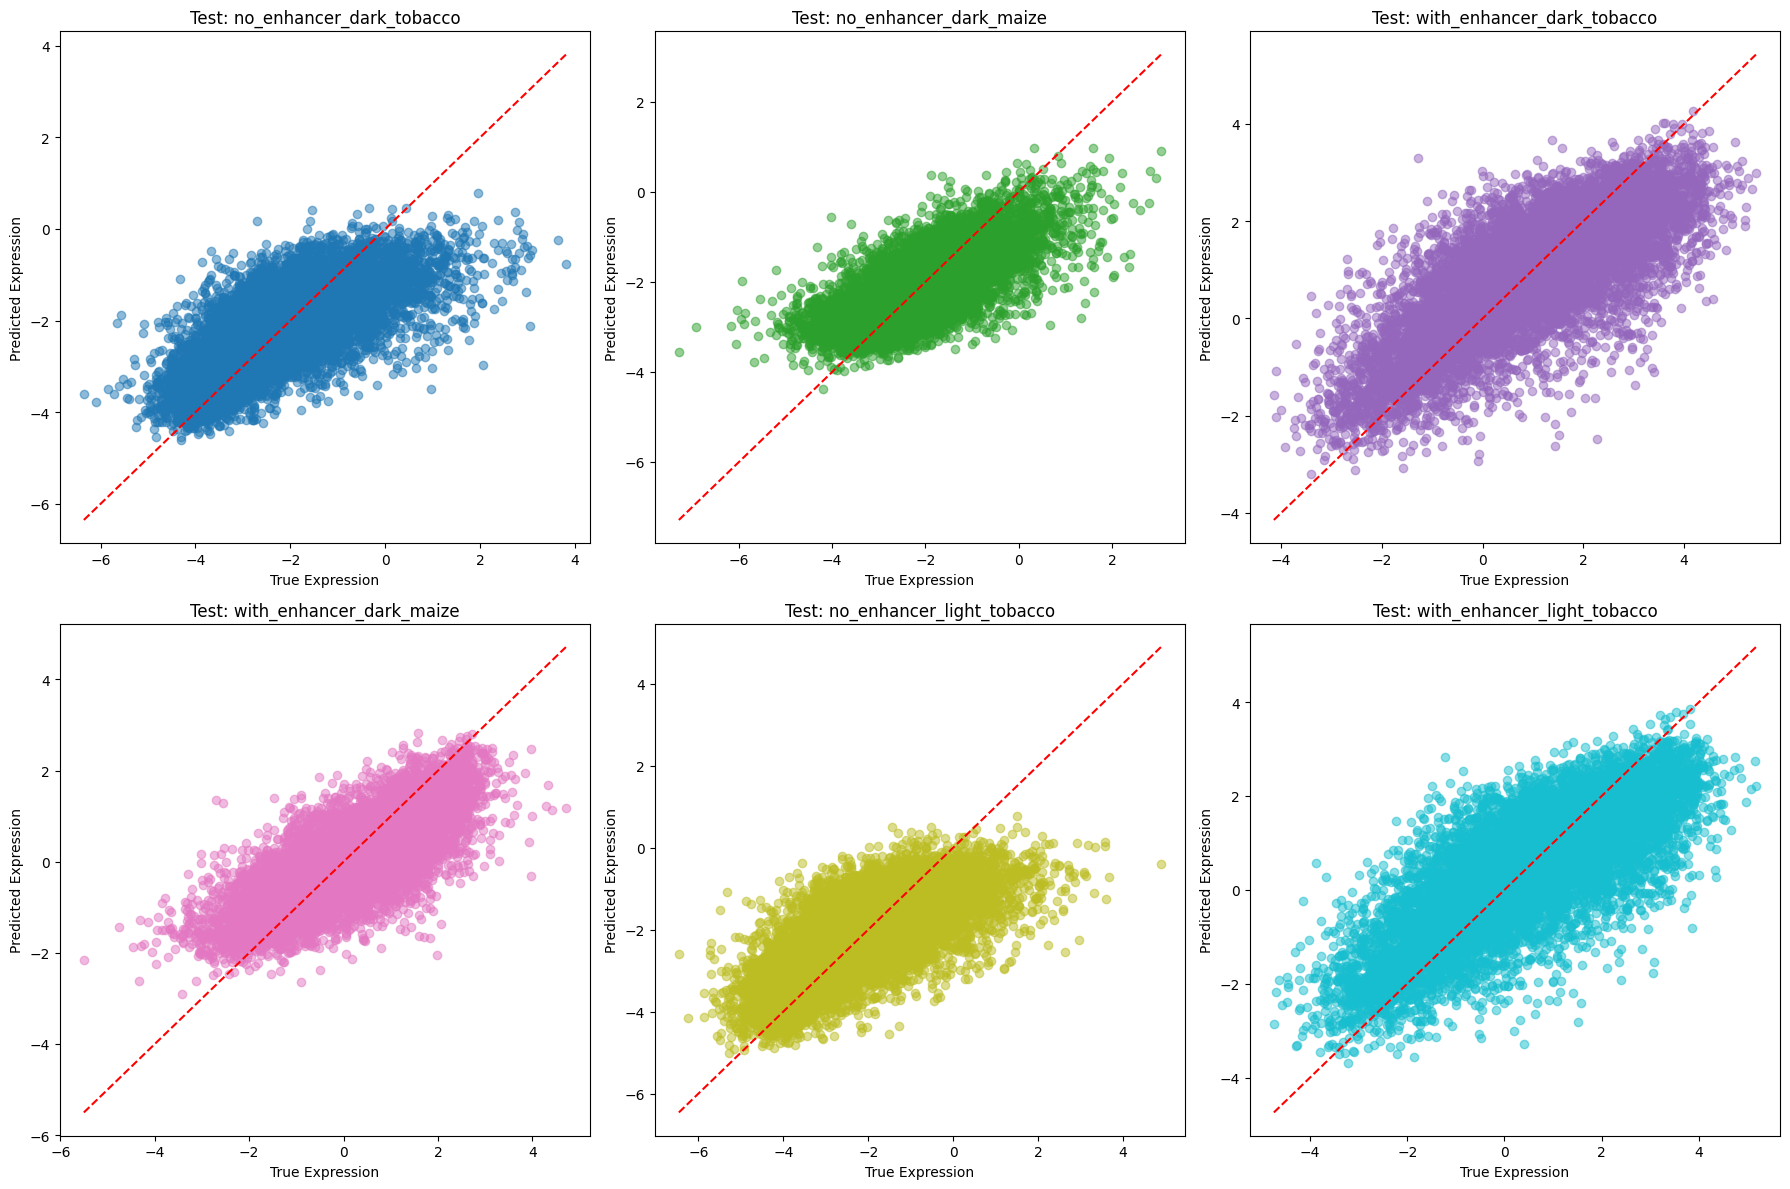

In [40]:
import matplotlib.cm as cm

colors = cm.get_cmap('tab10', len(COND_COLS)).colors

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Create a 2x3 grid of subplots
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for j, chosen_col in enumerate(COND_COLS):
    model = models[chosen_col]
    y_test = Y_test[:, j]
    test_pred = model.predict(X_test)

    ax = axes[j] # Get the current subplot axis
    ax.scatter(y_test, test_pred, alpha=0.5, color=colors[j])
    ax.set_xlabel("True Expression")
    ax.set_ylabel("Predicted Expression")
    ax.set_title(f"Test: {chosen_col}")

    min_val = min(y_test.min(), test_pred.min())
    max_val = max(y_test.max(), test_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--', color='red')

plt.tight_layout() # Adjust layout to prevent overlaps
plt.show()

In [37]:
results_df.to_csv("xgboost_wide_results.csv", index=False)
print("Saved: xgboost_wide_results.csv")

Saved: xgboost_wide_results.csv
